#### DS2000 & DS2001 Programming with Data & Practicum

# Homework 10: Sample Sizes and Confidence Intervals

### 44 Points

## Due Friday, April 4, 10:00 PM


**Reading**: 
* [Chap 13 Estimation](https://inferentialthinking.com/chapters/13/Estimation.html)
* [Chap 14 Why the Mean Matters](https://inferentialthinking.com/chapters/14/Why_the_Mean_Matters.html)

In [1]:
# Don't change this cell; just run it. 

import numpy as np
from datascience import *

# These lines do some fancy plotting magic.",
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

import otter
grader = otter.Notebook("hw10.ipynb")

## 1. Bounding the Tail of a Distribution

A community has an average age of 45 years with a standard deviation of 5 years.

In each part below, fill in the blank with a percent that makes the statement true **without further assumptions**, and explain your answer.

*Note:* No credit will be given for loose bounds such as "at least 0%" or "at most 100%". Give the best answer that is possible with the information given.

**Question 1.1. (2 pts)** At least _______% of the people are between 25 and 65 years old. 


93.75

**Question 1.2. (2 pts)** At most _______% of the people have ages that are not in the range 25 years to 65 years. 


6.25

**Question 1.3. (2 pts)** At most _______% of the people are more than 65 years old.

*Hint:* If you're stuck, try thinking about what the distribution may look like in this case.


3.125

## 2. Sample Size and Confidence Level

A data science class at the large Data 80 College wants to estimate the percent of Facebook users among students at the school. To do this, they need to take a random sample of students. You can assume that their method of sampling is equivalent to drawing at random with replacement from students at the school.

**Question 2.1. (3 pts)** Before starting this exercise, please review [Section 14.6](https://inferentialthinking.com/chapters/14/6/Choosing_a_Sample_Size.html#the-sample-size) of the textbook. Your work will go much faster that way. 

Assign `smallest` to the smallest number of students they should sample to ensure that a **95%** confidence interval for the parameter has a width of no more than 6% from left end to right end. 

*Note:* While the true smallest sample size would have to be an integer, please leave your answer in decimal format for the sake of our tests.


In [2]:
smallest = (4*(0.5/0.06))**2
smallest

1111.1111111111113

In [3]:
grader.check("q2_1")

q2_1 results: All test cases passed!

**Question 2.2. (2 pts)** Suppose the data science class decides to construct a 90% confidence interval instead of a 95% confidence interval, but they still require that the width of the interval is no more than 6% from left end to right end. Will they need the same sample size as in Question 2.1? Pick the right answer and explain further without calculation. 

1. Yes, they must use the same sample size.
2. No, a smaller sample size will work.
3. No, they will need a bigger sample.


2) No, a smaller sample size will work because lowering the confidence interval means decreasing the range of values and therefore decreasing the number of SDs. So, the sample size would be determined by squaring a smaller value of the SD, leading to a smaller sample size.

**Question 2.3. (3 pts)** The professor tells the class that a 90% confidence interval for the parameter is constructed exactly like a 95% confidence interval, except that you have to go only 1.65 SDs on either side of the estimate ($\pm$1.65) instead of 2 SDs on either side ($\pm$2). Assign `smallest_num` to the smallest number of students they should sample to ensure that a **90%** confidence interval for the parameter has a width of no more than 6% from left end to right end? 

*Note:* While the true smallest sample size would have to be an integer, please leave your answer in decimal format for the sake of our tests.

In [4]:
smallest_num = ((1.65*2)*(0.5/0.06))**2
smallest_num

756.25

In [5]:
grader.check("q2_3")

q2_3 results: All test cases passed!

For this next exercise, please consult [Section 14.3.4](https://inferentialthinking.com/chapters/14/3/SD_and_the_Normal_Curve.html#the-standard-normal-cdf) of the textbook for similar examples.

The students are curious about how the professor came up with the value 1.65 in Question 2.3. She says she ran the following two code cells. The first one calls the `datascience` library function `plot_normal_cdf`, which displays the proportion that is at most the specified number of SDs above average under the normal curve plotted with standard units on the horizontal axis. You can find the documentation [here](http://data8.org/datascience/util.html#datascience.util.plot_normal_cdf).

*Note:* The acronym `cdf` stands for `cumulative distribution function`. It measures the proportion to the left of a specified point under a probability histogram.

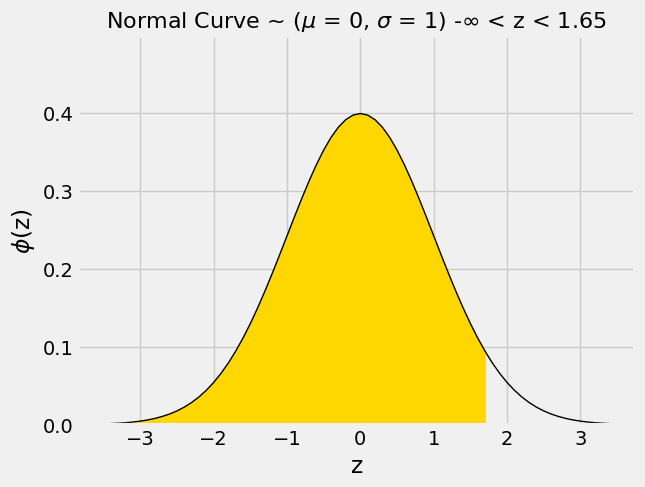

In [6]:
plot_normal_cdf(1.65)

To run the second cell, the professor had to first import a Python library for probability and statistics:

In [7]:
from scipy import stats

Then she used the `norm.cdf` method in the library to find the gold proportion above.

In [8]:
stats.norm.cdf(1.65)

0.9505285319663519

**Question 2.4. (3 pts)** This shows that the percentage in a normal distribution that is at most 1.65 SDs above average is about **95%**. Explain why 1.65 is the right number of SDs to use when constructing a **90%** confidence interval. 


The 1.65 SDs is used only for that 5% above the average for 95% of the normal distribution. A 90% confidence interval will have 5% both below and above the average that falls outside of this interval, so it will have 1.65 SDs on each of these sides. This is to say that 5% correlates to a SD of 1.65, which can be to the right for 95% when above the average and to the left and right when over a 90% confidence interval.

The reason 1.65 is the correct number of SDs for a confidence interval of 90% is because a 90% confidence interval will be more compact than a 95% confidence interval. S,o there will be less deviation for the 90% confidence interval than for the 95% confidence interval.

In [9]:
# Just run this cell, do not change it.

stats.norm.cdf(2.33)

0.99009692444083575

**Question 2.5. (2 pts)** The cell above shows that the proportion that is at most 2.33 SDs above average in a normal distribution is 99%. Assign `option` to the right option to fill in the blank: 

If you start at the estimate and go 2.33 SDs on either side, then you will get a _______% confidence interval for the parameter.

1. 99.5
2. 99
3. 98.5
4. 98


In [10]:
option = 4
option

4

In [11]:
grader.check("q2_5")

q2_5 results: All test cases passed!

## 3. Polling and the Normal Distribution

Michelle is a statistical consultant, and she works for a group that supports Proposition 88 (which would mandate labeling of all horizontal and vertical axes), called Yes on 88.  They want to know how many Californians will vote for the proposition.

Michelle polls a uniform random sample of all California voters, and she finds that 210 of the 400 sampled voters will vote in favor of the proposition. We have provided a table `sample_with_proportions` for you below which has 3 columns: the first two columns are identical to `sample`. The third column contains the proportion of total voters that chose each option.

In [12]:
sample = Table().with_columns(
    "Vote",  make_array("Yes", "No"),
    "Count", make_array(210,   190))

sample_size = sum(sample.column("Count"))
sample_with_proportions = sample.with_column("Proportion", sample.column("Count") / sample_size)
sample_with_proportions

Vote,Count,Proportion
Yes,210,0.525
No,190,0.475


**Question 3.1. (3 pts)** Michelle wants to use 10,000 bootstrap resamples to compute a confidence interval for the proportion of all California voters who will vote Yes.  

Fill in the next cell to simulate an empirical distribution of Yes proportions. Use bootstrap resampling to simulate 10,000 election outcomes, and assign `resample_yes_proportions` to contain the Yes proportion of each bootstrap resample. Then, visualize `resample_yes_proportions` with a histogram. **You should see a bell shaped curve centered near the proportion of Yes (which is 0.525) in the original sample.** 

*Hint:* The function `sample_proportions` may be useful here, since the action of sample_proportions -- using the same sample size as Michelle's and using the proportion the same as that of Michelle's sample -- is equivalent to bootstrap resampling.


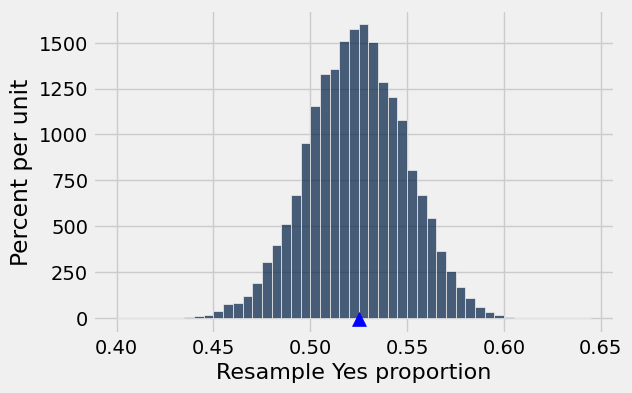

In [13]:
proportions = make_array(0.525, 0.475) 
resample_yes_proportions = make_array()
for i in np.arange(10000):
    resample = sample_proportions(sample_size, proportions)
    resample_yes_proportions = np.append(resample_yes_proportions, resample.item(
        0))
Table().with_column("Resample Yes proportion", resample_yes_proportions).hist(bins=np.arange(.4, .65, .005))
plt.scatter(0.525, -0.05, marker='^', color='blue', s=100);

In [14]:
grader.check("q3_1")

q3_1 results: All test cases passed!

**Question 3.2. (3 pts)** Why does the Central Limit Theorem (CLT) apply in this situation, and how does it explain the distribution we see above? 


The Central Limit Theorem applies in this situation because the above distribution is a mostly normal-shaped distribution. The majority of values are centered around the original sample value of 0.525, and decrease as values further deviate from this sample value. So, the above distribution represents CLT, and CLT represents it, because - since proportions are means - it shows that the distribution of these random samples of proportions/means tends to be somewhat normal.

Recall the Central Limit Theorem for the Sample Mean says that:
$$\texttt{SD of sample means} = {\text{SD of population} \over \sqrt{\text {sample size}}}$$


In a population whose members are 0 and 1, there is a simple formula for the **standard deviation of that population**:

$$\texttt{SD of population} = \sqrt{(\text{proportion of 0s}) \times (\text{proportion of 1s})}$$

(Figuring out this formula, starting from the definition of the standard deviation, is an fun exercise for those who enjoy algebra.)

**Question 3.3. (3 pts)** Using only the Central Limit Theorem and the numbers of Yes and No voters in our sample of 400, *algebraically* compute the predicted standard deviation of the `resample_yes_proportions` array. Assign this number to `approximate_sd`. **Do not access the data in `resample_yes_proportions` in any way.** 

Remember that the standard deviation of the sample means can be computed from the population SD and the size of the sample (the formula above might be helpful). If we do not know the population SD, we can use the sample SD as a reasonable approximation in its place. [This section](https://inferentialthinking.com/chapters/14/5/Variability_of_the_Sample_Mean.html#the-sd-of-all-the-sample-means) of the textbook also may be helpful.


In [15]:
approximate_sd = ((0.475*0.525)/(400))**(1/2)
approximate_sd

0.02496873044429772

In [16]:
grader.check("q3_3")

q3_3 results: All test cases passed!

**Question 3.4. (2 pts)** Compute the standard deviation of the array `resample_yes_proportions`, which will act as an approximation to the true SD of the possible sample proportions. This will help verify whether your answer to Question 3.3 is approximately correct. 


In [17]:
exact_sd = np.std(resample_yes_proportions)
exact_sd

0.025165011959812383

In [18]:
grader.check("q3_4")

q3_4 results: All test cases passed!

**Question 3.5. (3 pts)** **Again, without accessing `resample_yes_proportions` in any way**, compute an approximate 95% confidence interval for the proportion of Yes voters in California. 

The cell below draws your interval as a red bar below the histogram of `resample_yes_proportions`; use that to verify that your answer looks right.

*Hint:* How many SDs corresponds to 95% of the distribution promised by the CLT? Recall the discussion in the textbook [here](https://inferentialthinking.com/chapters/14/3/SD_and_the_Normal_Curve.html).


In [19]:
lower_limit = 0.525 - 2*approximate_sd
upper_limit = 0.525 + 2*approximate_sd
print('lower:', lower_limit, 'upper:', upper_limit)

lower: 0.47506253911140456 upper: 0.5749374608885954


In [20]:
grader.check("q3_5")

q3_5 results: All test cases passed!

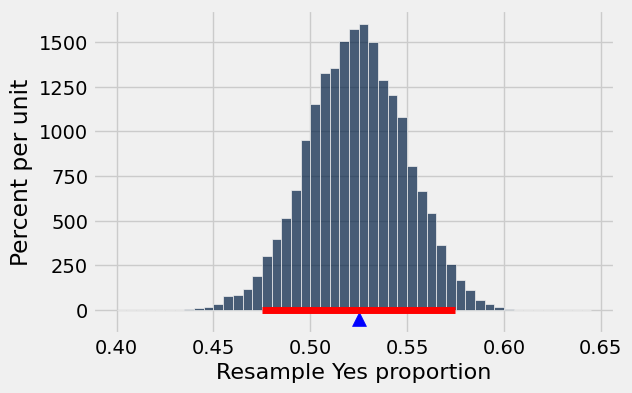

In [21]:
# Run this cell to plot your confidence interval.
Table().with_column("Resample Yes proportion", resample_yes_proportions).hist(bins=np.arange(.4, .65, .005))
plt.scatter(0.525, -0.5, marker='^', color='blue', s=100)
plt.plot(make_array(lower_limit, upper_limit), make_array(0, 0), color='red', lw=5);

Your confidence interval should overlap the number 0.5. Since anything less than 0.5 would indicate that Proposition 88 is losing, given this confidence interval, we can't be very sure whether Proposition 88 is winning, even though the sample Yes proportion is a bit above 0.5. 

The Yes on 88 campaign really needs to know whether they're winning.  It's impossible to be absolutely sure without polling the whole population, but they'd be okay if the standard deviation of the sample means were only 0.005. (Note that the SD computed in Question 3.4 was quite a bit higher than 0.005.) They ask Michelle to run a new poll with a sample size that's large enough to achieve that.  (Polling is expensive, so the sample also shouldn't be bigger than necessary.)

Michelle consults Chapter 14 of your textbook.  She used the conservative assumption that the population standard deviation is 0.5 (coding Yes voters as 1 and No voters as 0).  Under that assumption, Michelle decides that a sample of 10,000 (instead of 400) would suffice.

**Question 3.6. (3 pts)** Does Michelle's sample size achieve the desired standard deviation of sample means? What SD would you achieve with a smaller sample size? A higher sample size? To explore this, first compute the SD of sample means obtained by using Michelle's sample size.


In [22]:
conservative_population_sd = 0.5
michelle_sample_size = 10000
michelle_sample_mean_sd = conservative_population_sd/((michelle_sample_size
                                                      )**(1/2))
print("With Michelle's sample size, you would predict a sample mean SD of %f." % michelle_sample_mean_sd)

With Michelle's sample size, you would predict a sample mean SD of 0.005000.


In [23]:
grader.check("q3_6")

q3_6 results: All test cases passed!

**Question 3.7. (3 pts)** Next, compute the SD of sample means that you would get from a smaller sample size. Ideally, you should pick a number that is significantly smaller, but any sample size smaller than Michelle's will do. 


In [24]:
smaller_sample_size = 100
smaller_sample_mean_sd = conservative_population_sd/((smaller_sample_size
                                                     )**(1/2))
print("With this smaller sample size, you would predict a sample mean SD of %f" % smaller_sample_mean_sd)

With this smaller sample size, you would predict a sample mean SD of 0.050000


In [25]:
grader.check("q3_7")

q3_7 results: All test cases passed!

**Question 3.8. (3 pts)** Finally, compute the SD of sample means that you would get from a larger sample size. Here, a number that is significantly larger would make any difference more obvious, but any sample size larger than Michelle's will do. 


In [26]:
larger_sample_size = 50000
larger_sample_mean_sd = conservative_population_sd/((larger_sample_size
                                                    )**(1/2))
print("With this larger sample size, you would predict a sample mean SD of %f" % larger_sample_mean_sd)

With this larger sample size, you would predict a sample mean SD of 0.000022


In [27]:
grader.check("q3_8")

q3_8 results: All test cases passed!

**Question 3.9. (2 pts)** Based off of this, was Michelle's sample size approximately the minimum sufficient sample, given her assumption that the sample SD is the same as the population SD? Assign `min_sufficient` to `True` if 10,000 was indeed approximately the minimum sufficient sample, and `False` if it wasn't. 


In [28]:
min_sufficient = True
min_sufficient

True

In [29]:
grader.check("q3_9")

q3_9 results: All test cases passed!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [30]:
grader.check_all()

q2_1 results: All test cases passed!

q2_3 results: All test cases passed!

q2_5 results: All test cases passed!

q3_1 results: All test cases passed!

q3_3 results: All test cases passed!

q3_4 results: All test cases passed!

q3_5 results: All test cases passed!

q3_6 results: All test cases passed!

q3_7 results: All test cases passed!

q3_8 results: All test cases passed!

q3_9 results: All test cases passed!

**You've completed Homework 10!**

Please save your notebook, download a pdf version of the notebook, and submit it to Gradescope.